# Project 4 Analysis

_Isaiah Osborne_

## Import Data

Person 3: Data Exploration & Visualization
- Perform initial dataset exploration (data summary, descriptive statistics, checking for missing values).
- Create visualizations for key findings:
- Property value differences based on covenant density.
- Loan approval disparities.
- Demographic and economic patterns.
- Ensure visualizations effectively support the report's key claims.
Help with slide preparation for the presentation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("../../Data/mortgage_covenant_data.csv")

## Dataset Exploration

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100931 entries, 0 to 100930
Data columns (total 14 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   activity_year                      100931 non-null  int64  
 1   census_tract                       99915 non-null   float64
 2   derived_race                       100931 non-null  object 
 3   action_taken                       100931 non-null  int64  
 4   loan_amount                        100931 non-null  float64
 5   property_value                     83491 non-null   float64
 6   income                             88200 non-null   float64
 7   interest_rate                      78125 non-null   float64
 8   tract_minority_population_percent  100931 non-null  float64
 9   tract_to_msa_income_percentage     100931 non-null  float64
 10  denial_reason-1                    100931 non-null  int64  
 11  covenant_count                     1009

`covenant_density` has several missing values - let's see what's going with it.

In [4]:
data["covenant_density"].value_counts()

covenant_density
Low (1-50)          4537
Very High (>200)    3140
Medium (51-100)     1772
High (101-200)      1720
Name: count, dtype: int64

It looks like the number of covenants is fairly unbalanced? Most of these don't have any covenants, which is good! We'll need to make sure this unbalanced data doesn't show up as bias in our algorithms. It could just try to sweep the covenants "under the rug" and not account for their impact.

## Data Bias

Let's see if we can unearth any sort of bias on our dataset.

In [5]:
data

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100926,2023,2.700902e+10,Race Not Available,6,255000.0,265000.0,NaN,6.125,4.88,106.18,10,0.0,False,NaN
100927,2023,2.706778e+10,Race Not Available,6,185000.0,335000.0,NaN,6.125,46.58,74.68,10,0.0,False,NaN
100928,2023,2.714948e+10,Race Not Available,6,65000.0,75000.0,NaN,6.750,20.14,118.83,10,0.0,False,NaN
100929,2023,2.705913e+10,Race Not Available,6,545000.0,525000.0,NaN,5.000,6.84,90.07,10,0.0,False,NaN


In [6]:
data.value_counts("derived_race")

derived_race
White                                        63627
Race Not Available                           22811
Asian                                         5905
Black or African American                     5199
Joint                                         2427
American Indian or Alaska Native               709
2 or more minority races                       135
Native Hawaiian or Other Pacific Islander      113
Free Form Text Only                              5
Name: count, dtype: int64

Our race data here is pretty skewed to not have race... let's see how the prices breakdown across the different races.

In [7]:
data

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100926,2023,2.700902e+10,Race Not Available,6,255000.0,265000.0,NaN,6.125,4.88,106.18,10,0.0,False,NaN
100927,2023,2.706778e+10,Race Not Available,6,185000.0,335000.0,NaN,6.125,46.58,74.68,10,0.0,False,NaN
100928,2023,2.714948e+10,Race Not Available,6,65000.0,75000.0,NaN,6.750,20.14,118.83,10,0.0,False,NaN
100929,2023,2.705913e+10,Race Not Available,6,545000.0,525000.0,NaN,5.000,6.84,90.07,10,0.0,False,NaN


In [8]:
data.value_counts("covenant_density")

covenant_density
Low (1-50)          4537
Very High (>200)    3140
Medium (51-100)     1772
High (101-200)      1720
Name: count, dtype: int64

## Racial Representation

In [ ]:
data["derived_race"].value_counts(normalize=True)

derived_race
White                                        0.630401
Race Not Available                           0.226006
Asian                                        0.058505
Black or African American                    0.051510
Joint                                        0.024046
American Indian or Alaska Native             0.007025
2 or more minority races                     0.001338
Native Hawaiian or Other Pacific Islander    0.001120
Free Form Text Only                          0.000050
Name: proportion, dtype: float64

Overall, $66\%$ of our dataset is white, with another $22\%$ not having any race data. Only $12\%$ of our dataset is any sort of minority - let's see if this pattern continues when we add in covenants. How does this compare to the "actual" population proportion of Hennepin County?

In [10]:
print(f"Percentage of Hennepin County that's Black/African American: {171511/1281565:.2%}")


Percentage of Hennepin County that's Black/African American: 13.38%


So, our dataset is significantly underrepresenting the racial mixture of Hennepin County. This is something to look at...

In [11]:
for covenant in data["covenant_density"].unique():
    filteredData = data[data["covenant_density"] == covenant]
    print("Covenant:", covenant)
    print(filteredData["derived_race"].value_counts(normalize=True))

Covenant: nan
Series([], Name: proportion, dtype: float64)
Covenant: Medium (51-100)
derived_race
White                               0.606659
Race Not Available                  0.250564
Black or African American           0.058126
Asian                               0.045147
Joint                               0.029345
American Indian or Alaska Native    0.008465
2 or more minority races            0.001693
Name: proportion, dtype: float64
Covenant: Low (1-50)
derived_race
White                                        0.560282
Race Not Available                           0.245096
Black or African American                    0.094115
Asian                                        0.058188
Joint                                        0.031959
American Indian or Alaska Native             0.007494
2 or more minority races                     0.001543
Native Hawaiian or Other Pacific Islander    0.001322
Name: proportion, dtype: float64
Covenant: High (101-200)
derived_race
White            

It looks like our missing value percentages are fairly consistent across our dataset, which is encouraging. At least our data collection process looks consistently biased, which is helpful.

## Race vs. Price

In [12]:
racePrices = data.groupby(["derived_race"])["property_value"].mean().reset_index()

In [13]:
racePrices

,derived_race,property_value
0,2 or more minority races,318364.485981
1,American Indian or Alaska Native,274190.647482
2,Asian,398269.071310
3,Black or African American,353771.848054
4,Free Form Text Only,363000.000000
5,Joint,404152.376286
6,Native Hawaiian or Other Pacific Islander,257574.257426
7,Race Not Available,493788.216561
8,White,370072.639684


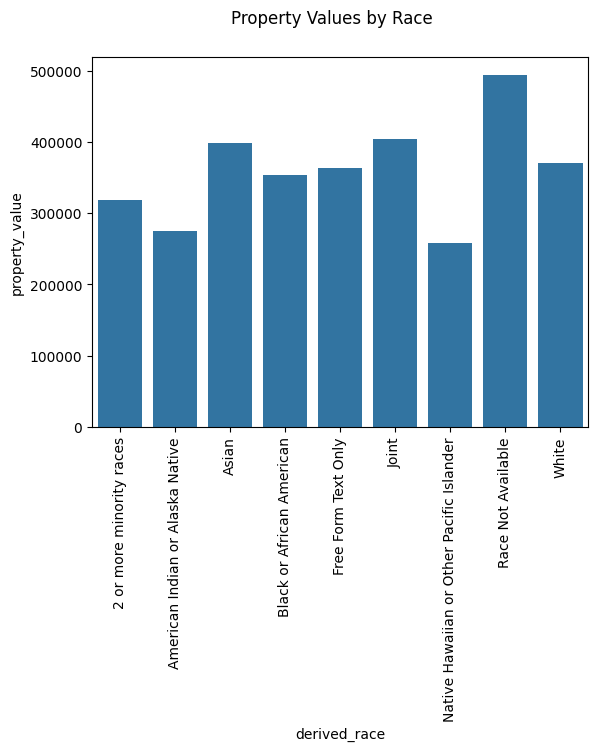

In [14]:
ax = sns.barplot(x=racePrices["derived_race"], y=racePrices["property_value"])
plt.suptitle("Property Values by Race")
ax.tick_params(axis="x", rotation=90)

It looks like race definitely has an impact on a house's price. Let's break this into covenant and none-covenant areas.

In [15]:
data["is-covenant"] = ~data["covenant_density"].isna()

In [16]:
racePrices = data.groupby(["is-covenant", "derived_race"])["property_value"].mean().reset_index()

In [17]:
racePrices

,is-covenant,derived_race,property_value
0,False,2 or more minority races,318333.333333
1,False,American Indian or Alaska Native,266239.837398
2,False,Asian,393576.975788
3,False,Black or African American,359317.877245
4,False,Free Form Text Only,363000.000000
5,False,Joint,393986.095017
6,False,Native Hawaiian or Other Pacific Islander,253651.685393
7,False,Race Not Available,483891.233570
8,False,White,356681.131674
9,True,2 or more minority races,318571.428571


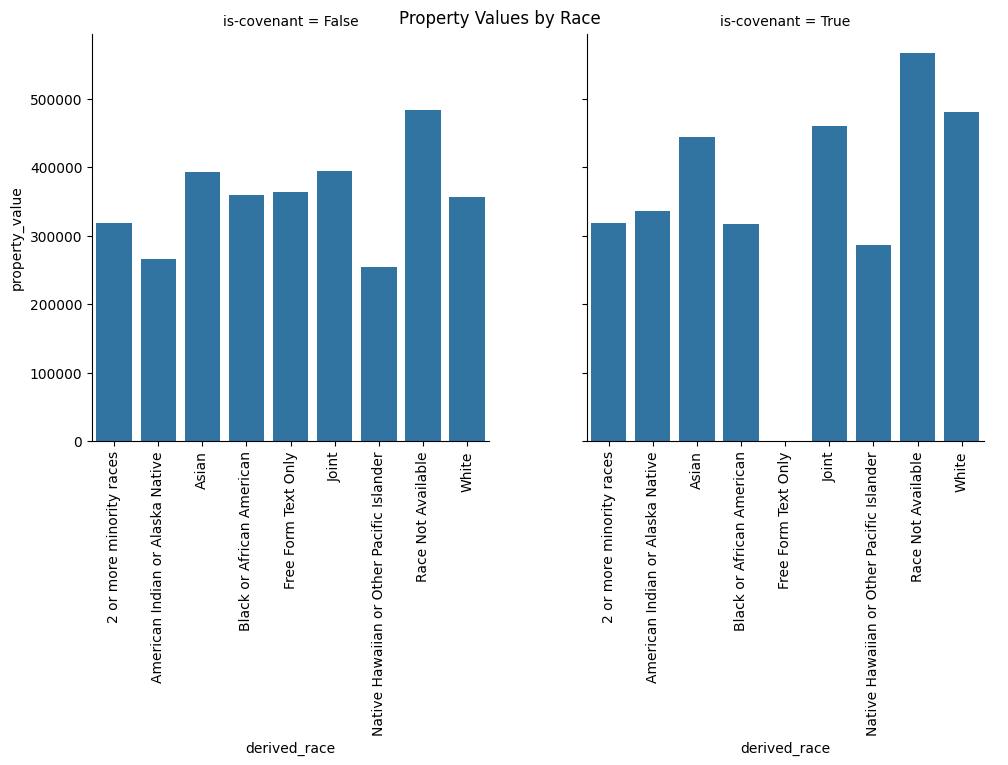

In [18]:
ax = sns.catplot(kind="bar", data=racePrices, x="derived_race", y="property_value", col="is-covenant")
plt.suptitle("Property Values by Race")
ax.tick_params(axis="x", rotation=90)

It looks like houses from areas with covenents are worth more than those that don't. It looks like there is probably some bias with their collection method, though - it looks like houses that have racial data are worth more than houses without? Not sure if this is statistically significant, but its an interesting result.

## Approval Rates by Race

In [20]:
approvalPrices = data.groupby(["derived_race"])["was_approved"].mean().reset_index()

In [21]:
approvalPrices

,derived_race,was_approved
0,2 or more minority races,0.659259
1,American Indian or Alaska Native,0.622003
2,Asian,0.707705
3,Black or African American,0.604155
4,Free Form Text Only,0.800000
5,Joint,0.744129
6,Native Hawaiian or Other Pacific Islander,0.566372
7,Race Not Available,0.405725
8,White,0.756063


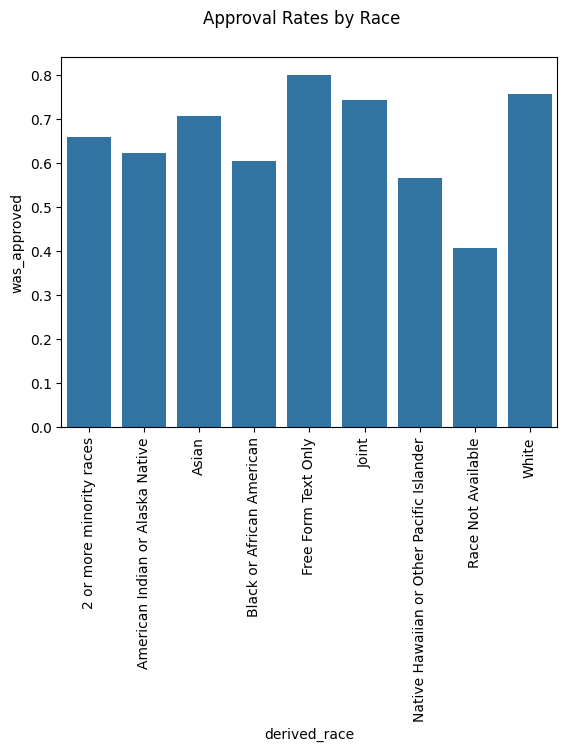

In [ ]:
ax = sns.barplot(x=approvalPrices["derived_race"], y=approvalPrices["was_approved"])
plt.suptitle("Approval Rates by Race")
ax.tick_params(axis="x", rotation=90)

Interestingly, despite the higher property values of the "race not available" properties, they actually have lower approval rates than other races. It looks like their data collection method is probably biased here...

In [25]:
data.groupby(["derived_race"])["derived_race"].count()

derived_race
2 or more minority races                       135
American Indian or Alaska Native               709
Asian                                         5905
Black or African American                     5199
Free Form Text Only                              5
Joint                                         2427
Native Hawaiian or Other Pacific Islander      113
Race Not Available                           22811
White                                        63627
Name: derived_race, dtype: int64